In [1]:
import arviz as az
import seaborn as sns
import os.path as op
import pandas as pd

In [2]:
bids_folder = '/data/ds-risk'

,n1_evidence_sd,n2_evidence_sd,risky_prior_mu,safe_prior_mu,risky_prior_std,safe_prior_std
n1_evidence_sd,1.000000,0.431813,-0.307675,0.123026,0.187542,0.072747
n2_evidence_sd,0.431813,1.000000,0.024694,0.366407,-0.224027,0.423804
risky_prior_mu,-0.307675,0.024694,1.000000,-0.168854,0.069188,0.017130
safe_prior_mu,0.123026,0.366407,-0.168854,1.000000,-0.189766,0.086541
risky_prior_std,0.187542,-0.224027,0.069188,-0.189766,1.000000,-0.379755
safe_prior_std,0.072747,0.423804,0.017130,0.086541,-0.379755,1.000000


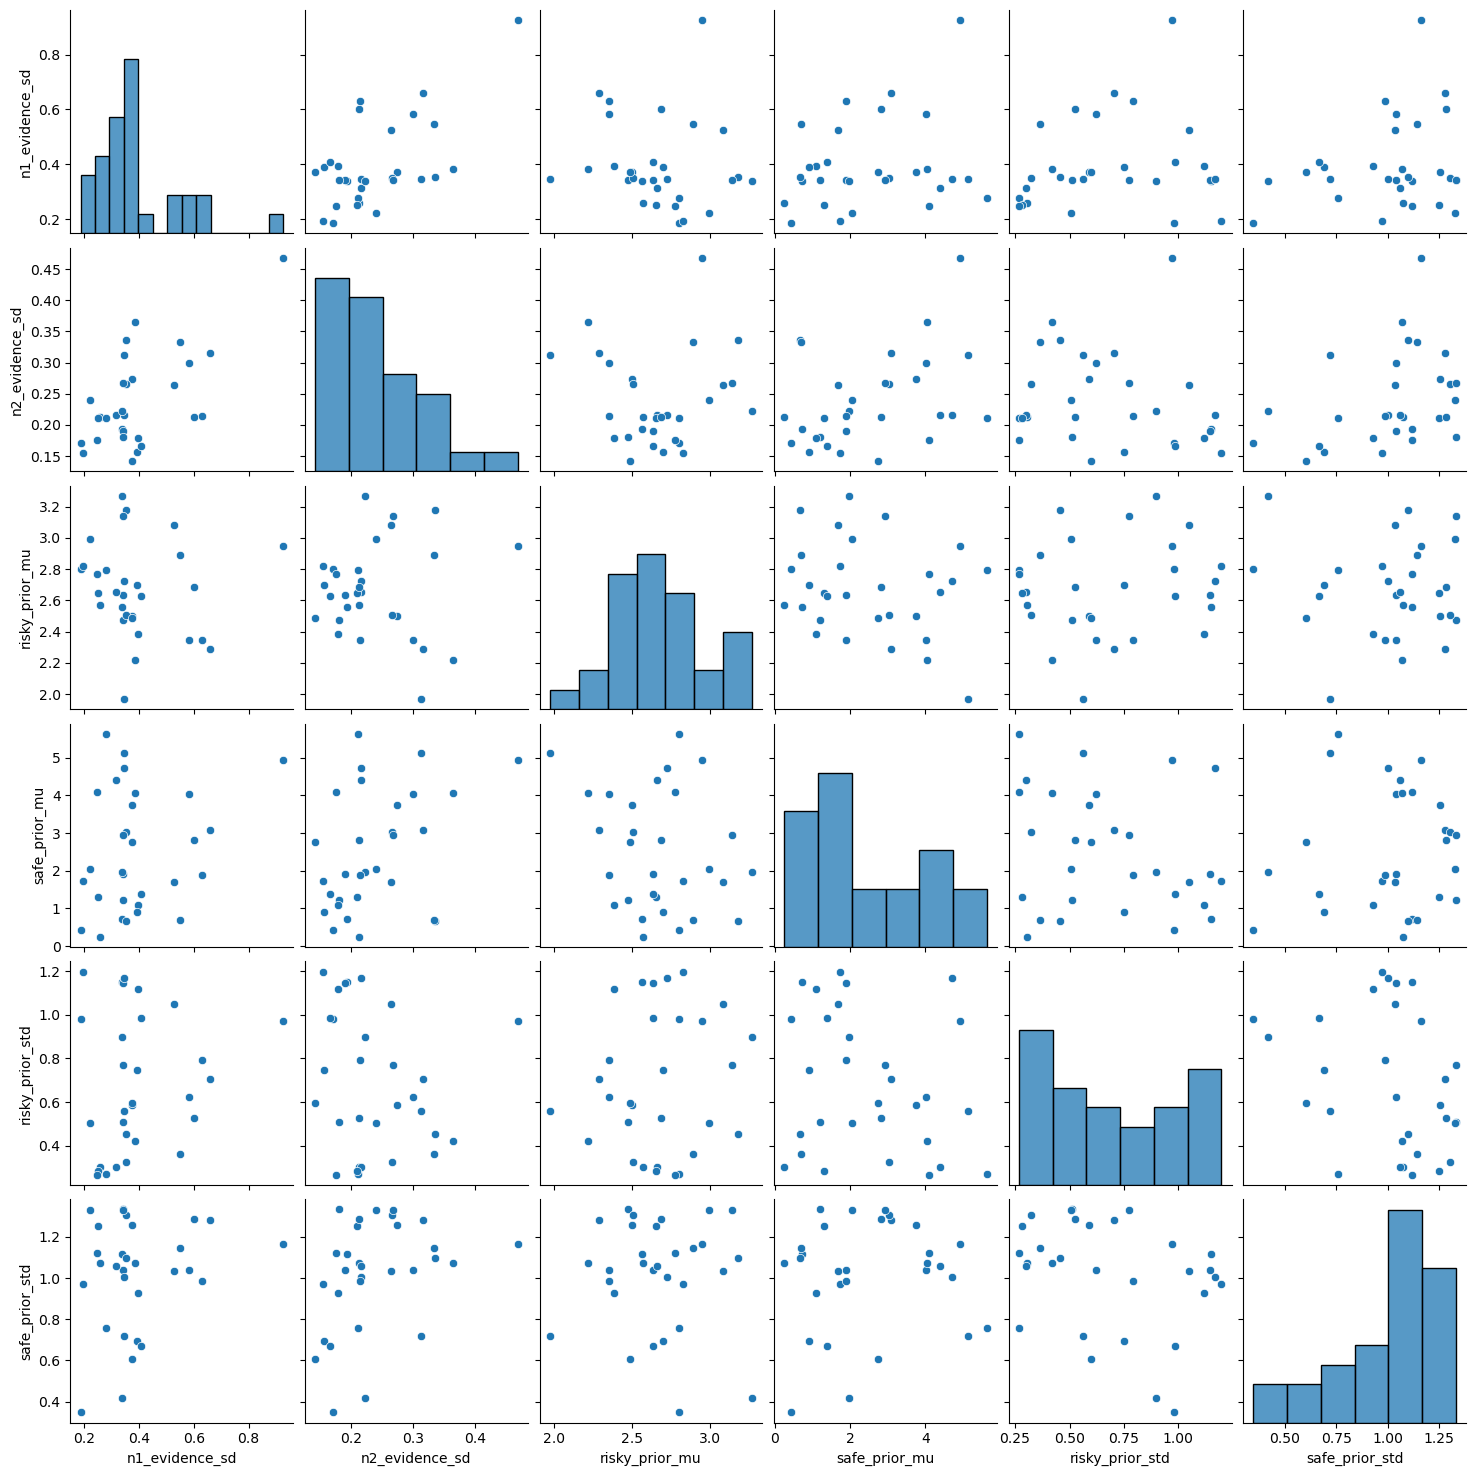

In [3]:
idata = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', 'model-1_trace.netcdf'))
n1 = idata.posterior['n1_evidence_sd'].to_dataframe().groupby('subject').mean()
n2 = idata.posterior['n2_evidence_sd'].to_dataframe().groupby('subject').mean()
risky_prior_mu = idata.posterior['risky_prior_mu'].to_dataframe().groupby('subject').mean()
safe_prior_mu = idata.posterior['safe_prior_mu'].to_dataframe().groupby('subject').mean()
risky_prior_sd = idata.posterior['risky_prior_std'].to_dataframe().groupby('subject').mean()
safe_prior_sd = idata.posterior['safe_prior_std'].to_dataframe().groupby('subject').mean()

df = pd.concat((n1, n2, risky_prior_mu,safe_prior_mu,risky_prior_sd, safe_prior_sd), axis=1)


import seaborn as sns
sns.pairplot(df)

n1_ = n1.copy()

df.corr(method='spearman')

,n1_evidence_sd,n2_evidence_sd,risky_prior_mu
n1_evidence_sd,1.000000,0.319689,-0.129255
n2_evidence_sd,0.319689,1.000000,0.130145
risky_prior_mu,-0.129255,0.130145,1.000000


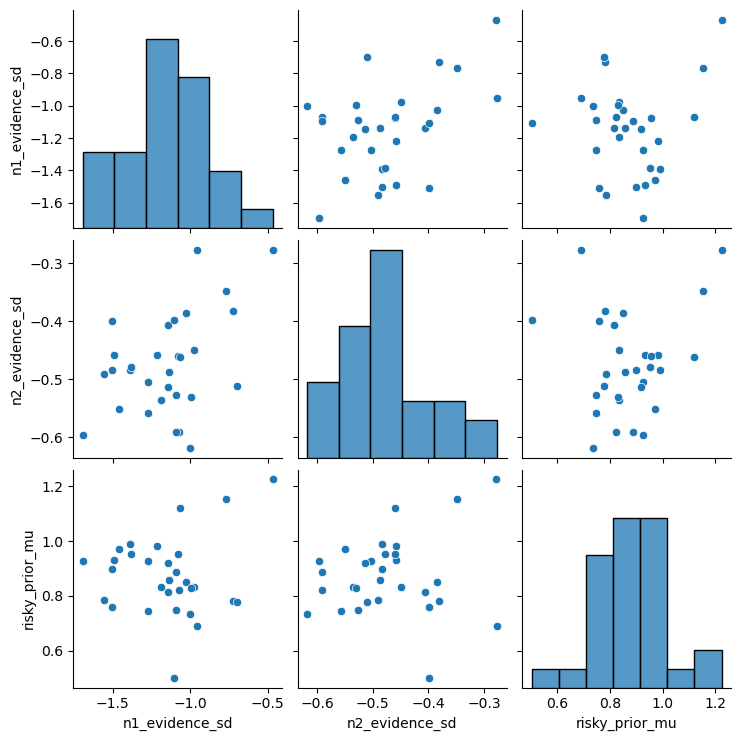

In [4]:
idata = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', 'model-neural33_trace.netcdf'))
n1 = idata.posterior['n1_evidence_sd'].to_dataframe().xs('Intercept', 0, 'n1_evidence_sd_regressors').groupby('subject').mean()
n2 = idata.posterior['n2_evidence_sd'].to_dataframe().xs('Intercept', 0, 'n2_evidence_sd_regressors').groupby('subject').mean()
risky_prior_mu = idata.posterior['risky_prior_mu'].to_dataframe().xs('Intercept', 0, 'risky_prior_mu_regressors').groupby('subject').mean()
n2 = idata.posterior['n2_evidence_sd'].to_dataframe().groupby('subject').mean()
risky_prior_mu = idata.posterior['risky_prior_mu'].to_dataframe().groupby('subject').mean()

df = pd.concat((n1, n2, risky_prior_mu), axis=1)


import seaborn as sns
sns.pairplot(df)
df.corr(method='spearman')


In [5]:
pd.concat((n1_, n1), keys=['simple', 'neural'], axis=1).corr(method='spearman')

,,simple,neural
,,n1_evidence_sd,n1_evidence_sd
simple,n1_evidence_sd,1.000000,0.838042
neural,n1_evidence_sd,0.838042,1.000000
